# Data Loading

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load dataset
df = pd.read_csv(r'C:\Users\shubh\Downloads\BankChurners.csv\BankChurners.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [2]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [3]:
# Drop the duplicates
df.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [4]:
df = df[df.columns[:-2]]

In [5]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [8]:
df = df.drop_duplicates()
df.shape

(10127, 21)

# Exploratory Data Analysis

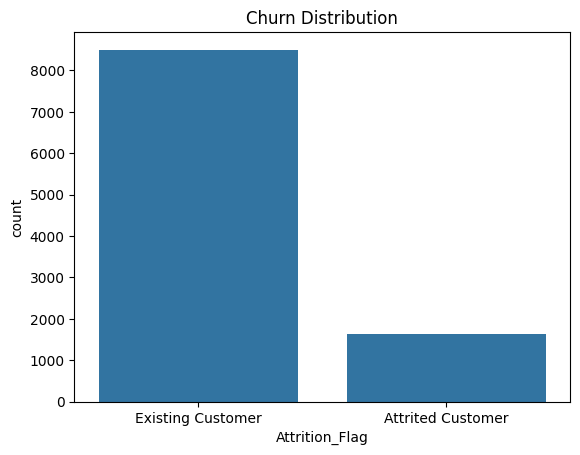

Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64

In [19]:
# check if class is imbalanced 

sns.countplot(x= "Attrition_Flag", data=df)
plt.title('Churn Distribution')
plt.show()

df['Attrition_Flag'].value_counts(normalize = True) * 100

We observe a clear class imbalance in the target variable. The majority class, representing existing customers, accounts for 83.94% of the data, while the minority class, representing churned customers, accounts for only 16.06%. This imbalance needs to be carefully addressed to ensure that predictive models are not biased toward the majority class.


<Axes: xlabel='Customer_Age'>

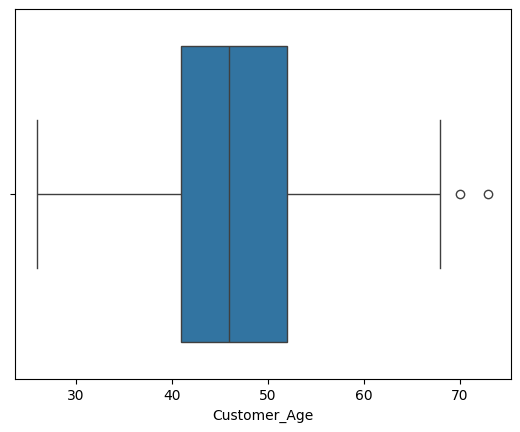

In [20]:
sns.boxplot(x = df['Customer_Age'])


<Axes: xlabel='Customer_Age', ylabel='Count'>

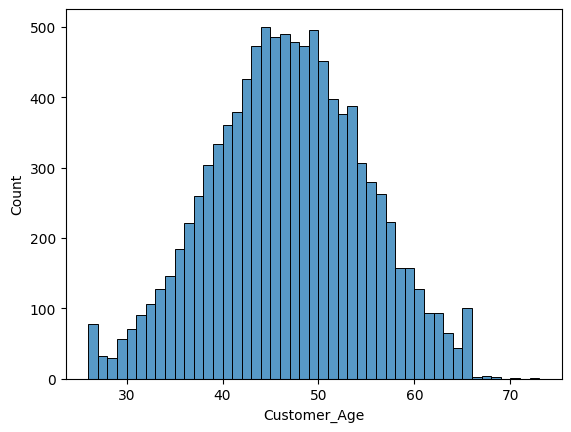

In [21]:
sns.histplot (df['Customer_Age'])

Most customers are concentrated between their late 30s and early 60s, with the median age around the mid-40s. There are a few outliers on the higher end, indicating some older customers above 70 years. The distribution appears fairly symmetric with no significant skewness.

In [22]:
import plotly.graph_objects as go
import plotly.io as pio

fig = make_subplots(
    rows=2, cols=2,subplot_titles=('','<b>Platinum Card Holders','<b>Blue Card Holders<b>','Residuals'),
    vertical_spacing=0.09,
    specs=[[{"type": "pie","rowspan": 2}       ,{"type": "pie"}] ,
           [None                               ,{"type": "pie"}]            ,                                      
          ]
)

fig.add_trace(
    go.Pie(values=df.Gender.value_counts().values,labels=['<b>Female<b>','<b>Male<b>'],hole=0.3,pull=[0,0.3]),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=['Female Platinum Card Holders','Male Platinum Card Holders'],
        values=df.query('Card_Category=="Platinum"').Gender.value_counts().values,
        pull=[0,0.05,0.5],
        hole=0.3
        
    ),
    row=1, col=2
)

fig.add_trace(
    go.Pie(
        labels=['Female Blue Card Holders','Male Blue Card Holders'],
        values=df.query('Card_Category=="Blue"').Gender.value_counts().values,
        pull=[0,0.2,0.5],
        hole=0.3
    ),
    row=2, col=2
)



fig.update_layout(
    height=800,
    showlegend=True,
    title_text="<b>Distribution Of Gender And Different Card Statuses<b>",
)
pio.renderers.default = "notebook" 
fig.show()


There are more samples of female in our dataset , but the percentage of difference is not very huge so we can say that genders are uniformly distributed 

In [23]:
fig = make_subplots(rows=2, cols=1)

tr1=go.Box(x=df['Dependent_count'],name='Dependent count Box Plot',boxmean=True)
tr2=go.Histogram(x=df['Dependent_count'],name='Dependent count Histogram')

fig.add_trace(tr1,row=1,col=1)
fig.add_trace(tr2,row=2,col=1)

fig.update_layout(height=700, width=1200, title_text="Distribution of Dependent counts (close family size)")
fig.show()

The distribution of Dependent counts is fairly normally distributed with a slight right skew

In [24]:
import plotly.express as px 

In [25]:
px.pie(df,names="Education_Level" , title='Proportion of Education Levels' , hole = 0.33)

If most of the customers with unknown education status lack any education, we can state that more than 70% of the customers have a formal education level. About 35% have a higher level of education

In [26]:
px.pie(df,names='Marital_Status',title='Propotion Of Different Marriage Statuses',hole=0.33)


Almost half of the customers i.e, 46.3% of customers are married and 38.9 % are Single , 

In [27]:
px.pie(df,names='Income_Category',title='Propotion Of Different Income Levels',hole=0.33)

In [28]:
px.pie(df,names='Card_Category',title='Propotion Of Different Card Categories',hole=0.33)

In [48]:
fig = make_subplots(rows=2, cols=1)

tr1=go.Box(x=df['Months_on_book'],name='Months on book Box Plot',boxmean=True)
tr2=go.Histogram(x=df['Months_on_book'],name='Months on book Histogram')

fig.add_trace(tr1,row=1,col=1)
fig.add_trace(tr2,row=2,col=1)

fig.update_layout(height=700, width=1200, title_text="Distribution of months the customer is part of the bank")
fig.show()

In [49]:
print('Kurtosis of Months on book features is : {}'.format(df['Months_on_book'].kurt()))

Kurtosis of Months on book features is : 0.40010012019986707


**The "Months_on_book" feature has a distribution close to normal, but with mildly heavier tails.

That means:

A few customers have unusually long or short tenure compared to the majority.

But not extreme — it’s just a small deviation from normality.**

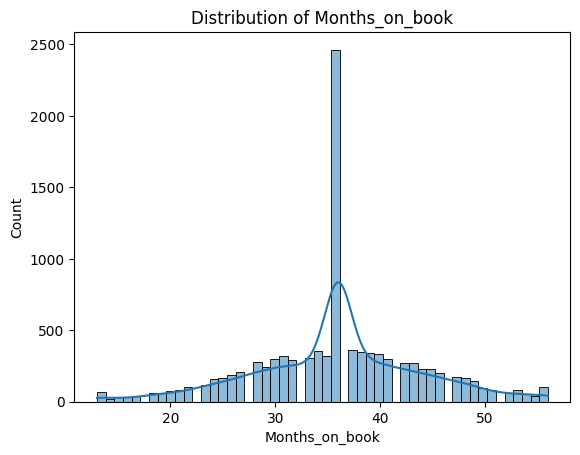

In [31]:

sns.histplot(df['Months_on_book'], kde=True)
plt.title("Distribution of Months_on_book")
plt.show()

In [32]:
df['TenureGroup'] = np.where(df['Months_on_book'] == 36, "36_months", "Other")

In [33]:
churn_rates = df.groupby('TenureGroup')['Attrition_Flag'].value_counts(normalize=True).unstack()
print(churn_rates)

Attrition_Flag  Attrited Customer  Existing Customer
TenureGroup                                         
36_months                0.174584           0.825416
Other                    0.156185           0.843815


### Chi-Square Test

In [34]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['TenureGroup'], df['Attrition_Flag'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square Statistic:", chi2)
print("p-value:", p)


Chi-Square Statistic: 4.543912047216421
p-value: 0.03303600975325984


Null hypothesis (H₀):
Attrition (churn) is independent of being at exactly 36 months vs. other tenures.

Alternative hypothesis (H₁):
Attrition is associated with being at 36 months.

If p < 0.05 --> reject Null Hypothesis 

p = 0.033 < 0.05

→ The difference is statistically significant.

That means customers with 36 months on book churn at a higher rate (~17.5%)

At the 3-year mark (36 months), customers are more likely to attrite.

Possible reasons:

Product lifecycle (e.g., card benefits expiring after 3 years).

Loyalty perks not being renewed.

Customers re-evaluating their card after a fixed term

In [35]:
fig = make_subplots(rows=2, cols=1)

tr1=go.Box(x=df['Total_Relationship_Count'],name='Total no. of products ',boxmean=True)
tr2=go.Histogram(x=df['Total_Relationship_Count'],name='Total no. of products ')
fig.add_trace(tr1,row=1,col=1)
fig.add_trace(tr2,row=2,col=1)

fig.update_layout(height=700, width=1200, title_text="Distribution of Total no. of products held by the customer")
fig.show()


The plots show that most customers hold 2–3 products, very few hold extremes (0 or ≥5). This feature captures engagement level

In [36]:
df = df.copy()

def engagement_category(x):
    if x <= 1:
        return "Low (0–1)"
    elif x <= 3:
        return "Medium (2–3)"
    else:
        return "High (≥4)"

df["EngagementLevel"] = df["Total_Relationship_Count"].apply(engagement_category)

churn_by_engagement = df.groupby("EngagementLevel")["Attrition_Flag"].value_counts(normalize=True).unstack()
print(churn_by_engagement)



Attrition_Flag   Attrited Customer  Existing Customer
EngagementLevel                                      
High (≥4)                 0.114306           0.885694
Low (0–1)                 0.256044           0.743956
Medium (2–3)              0.210259           0.789741


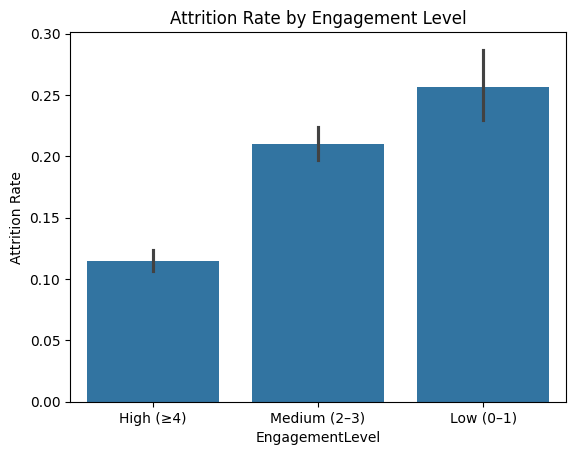

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x="EngagementLevel", y=(df["Attrition_Flag"]=="Attrited Customer").astype(int))
plt.title("Attrition Rate by Engagement Level")
plt.ylabel("Attrition Rate")
plt.show()


## Chi Square test for Engagagement Level

In [38]:
contigency1 = pd.crosstab(df['EngagementLevel'], df['Attrition_Flag'])
chi2e, pe, dofe , expectede = chi2_contingency(contingency)

print("Chi Square", chi2e)
print("p value" , pe)

Chi Square 4.543912047216421
p value 0.03303600975325984


Low engagement (0–1 products) → highest churn risk.

Medium engagement (2–3) → moderate churn.

High engagement (≥4) → very low churn (sticky customers

----------------------------------------------------------------------------
Customers with multiple products are more “locked in” and harder to lose.

Single-product customers are more likely to churn → prime target for cross-selling or retention campaigns

----------------------------------------------------------------------------------------

In [39]:
fig = make_subplots(rows=2, cols=1)

tr1=go.Box(x=df['Months_Inactive_12_mon'],name='number of months inactive Box Plot',boxmean=True)
tr2=go.Histogram(x=df['Months_Inactive_12_mon'],name='number of months inactive Histogram')

fig.add_trace(tr1,row=1,col=1)
fig.add_trace(tr2,row=2,col=1)

fig.update_layout(height=700, width=1200, title_text="Distribution of the number of months inactive in the last 12 months")
fig.show()

In [40]:
fig = make_subplots(rows=2, cols=1)

tr1=go.Box(x=df['Credit_Limit'],name='Credit_Limit Box Plot',boxmean=True)
tr2=go.Histogram(x=df['Credit_Limit'],name='Credit_Limit Histogram')

fig.add_trace(tr1,row=1,col=1)
fig.add_trace(tr2,row=2,col=1)

fig.update_layout(height=700, width=1200, title_text="Distribution of the Credit Limit")
fig.show()

In [41]:
fig = make_subplots(rows=2, cols=1)

tr1=go.Box(x=df['Total_Trans_Amt'],name='Total_Trans_Amt Box Plot',boxmean=True)
tr2=go.Histogram(x=df['Total_Trans_Amt'],name='Total_Trans_Amt Histogram')

fig.add_trace(tr1,row=1,col=1)
fig.add_trace(tr2,row=2,col=1)

fig.update_layout(height=700, width=1200, title_text="Distribution of the Total Transaction Amount (Last 12 months)")
fig.show()

We see that the distribution of the total transactions (Last 12 months) displays a multimodal distribution, meaning we have some underlying groups in our data; it can be an interesting experiment to try and cluster the different groups and view the similarities between them and what describes best the different groups which create the different modes in our distribution.

# Data PreProccesing 

In [9]:
# One Hot Encode the Categorical features 
# Convert binary features
df['Attrition_Flag'] = df['Attrition_Flag'].replace(
    {"Attrited Customer": 1, "Existing Customer": 0}
).astype(int)

df['Gender'] = df['Gender'].replace({'F': 1, 'M': 0}).astype(int)

# One-hot encode categorical features
categorical_cols = ['Education_Level', 'Income_Category', 'Marital_Status', 'Card_Category']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop ID column
df.drop(columns=['CLIENTNUM'], inplace=True)

print("✅ Preprocessing Done. Shape:", df.shape)
print("All numeric?", df.dtypes.value_counts())


✅ Preprocessing Done. Shape: (10127, 33)
All numeric? bool       17
int64      11
float64     5
Name: count, dtype: int64


C:\Users\shubh\AppData\Local\Temp\ipykernel_9544\2870058349.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Attrition_Flag'] = df['Attrition_Flag'].replace(
C:\Users\shubh\AppData\Local\Temp\ipykernel_9544\2870058349.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'F': 1, 'M': 0}).astype(int)


In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
# Setup subplots for Pearson & Spearman
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=('Pearson Correlation', 'Spearman Correlation')
)

# Use built-in color scale instead of custom list
colorscale = "RdBu"

# Loop through correlation methods
for i, method in enumerate(['pearson', 'spearman'], start=1):
    corr = df.corr(method=method, numeric_only=True)
    fig.add_trace(
        go.Heatmap(
            z=corr.values, 
            x=corr.columns, 
            y=corr.index,
            colorscale=colorscale,
            zmin=-1, zmax=1   # keeps color scale consistent
        ),
        row=i, col=1
    )

# Final layout
fig.update_layout(
    height=700, width=900,
    title_text="Numeric Correlations",
    hoverlabel=dict(bgcolor="white", font_size=14)
)
pio.renderers.default = "notebook_connected" 
fig.show()


In [44]:
# pearson_corr = df.corr(method='pearson')['Attrition_Flag'].sort_values(ascending=False)

# # Spearman correlation with Attrition_Flag
# spearman_corr = df.corr(method='spearman')['Attrition_Flag'].sort_values(ascending=False)

# print("🔹 Top 5 (Pearson):")
# print(pearson_corr.head(6))   # 6 because first will be Attrition_Flag itself

# print("\n🔹 Top 5 (Spearman):")
# print(spearman_corr.head(6))


Both Pearson (linear correlation) and Spearman (rank-based correlation) show similar patterns.

Attrition_Flag has moderate negative correlation with:

Total_Trans_Ct (number of transactions)

Total_Trans_Amt (transaction amount)
→ Suggests that customers who transact less are more likely to churn.

Total_Relationship_Count, Credit_Limit, and Months_on_book show weak positive correlation with retention (existing customers).

Features like Avg_Open_To_Buy, Total_Revolving_Bal, and Customer_Age show very low correlation individually.

Categorical one-hot encoded features (e.g., Income, Education, Marital Status) do not show strong direct correlation but may still contribute in non-linear models.

Overall, transaction-related variables are the strongest indicators of churn

## Interactive Plotly Histogram for Transactions

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag                  10127 non-null  int64  
 1   Customer_Age                    10127 non-null  int64  
 2   Gender                          10127 non-null  int64  
 3   Dependent_count                 10127 non-null  int64  
 4   Months_on_book                  10127 non-null  int64  
 5   Total_Relationship_Count        10127 non-null  int64  
 6   Months_Inactive_12_mon          10127 non-null  int64  
 7   Contacts_Count_12_mon           10127 non-null  int64  
 8   Credit_Limit                    10127 non-null  float64
 9   Total_Revolving_Bal             10127 non-null  int64  
 10  Avg_Open_To_Buy                 10127 non-null  float64
 11  Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 12  Total_Trans_Amt                 

# Data Upsampling Using SMOTE

In [16]:
from imblearn.over_sampling import SMOTE 
from collections import Counter 
numeric_df = df.select_dtypes(include=['int64', 'float64'])
X = numeric_df.drop("Attrition_Flag" , axis = 1)
y = numeric_df["Attrition_Flag"]

X_train, X_test , y_train , y_test = train_test_split(
    X,y ,
    test_size = 0.2 , 
    stratify=y , 
    random_state= 42
)

print("Before SMOTE:", y_train.value_counts(normalize=True))


# Apply SMOTE (only on the train)

smote = SMOTE(random_state=42)
X_train_res , y_train_res = smote.fit_resample(X_train,y_train)


print("After SMOTE:", y_train_res.value_counts(normalize=True))


X_train_res = pd.DataFrame(X_train_res, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

Before SMOTE: Attrition_Flag
0    0.839279
1    0.160721
Name: proportion, dtype: float64
After SMOTE: Attrition_Flag
0    0.5
1    0.5
Name: proportion, dtype: float64


**SMOTE (Synthetic Minority Oversampling Technique) will generate synthetic samples for the minority class by interpolating between existing minority points and their nearest neighbors.**

This approach balances the classes without simple duplication, which can lead to overfitting.

After SMOTE, the dataset becomes 50:50 balanced between attrited and existing customers.

The balanced training set allows downstream models (e.g., Logistic Regression, Random Forest, XGBoost) to learn decision boundaries more effectively, especially for the minority class.

In [17]:
df.head()



,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0,45,0,3,39,5,1,3,12691.0,777,...,True,False,False,False,True,False,False,False,False,False
1,0,49,1,5,44,6,1,2,8256.0,864,...,False,False,True,False,False,True,False,False,False,False
2,0,51,0,3,36,4,1,0,3418.0,0,...,False,True,False,False,True,False,False,False,False,False
3,0,40,1,4,34,3,4,1,3313.0,2517,...,False,False,True,False,False,False,True,False,False,False
4,0,40,0,3,21,5,1,0,4716.0,0,...,True,False,False,False,True,False,False,False,False,False


## Principal Component Analysis

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [19]:

# ===============================
# Scaling
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)  

In [20]:
# ===============================
# PCA
# ===============================
pca = PCA(n_components=0.95)  # keep 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)  # fit + transform on train
X_test_pca  = pca.transform(X_test_scaled)       # transform on test

print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_pca.shape)


Original shape: (8101, 15)
Reduced shape: (8101, 11)


#### 🧩 **Why PCA May Not Be Ideal Here**
- **Tree-based models** (like XGBoost, Random Forest) **don’t require PCA**:  
  They are **invariant to feature scaling** and handle **correlated features** well. PCA can actually **discard useful feature relationships** that tree splits could leverage.
- **Interpretability loss**: PCA creates **abstract components** instead of original features. For churn prediction, stakeholders usually want to know **which customer features** drive churn (e.g., `Total_Trans_Ct` or `Credit_Limit`). PCA would make feature importance **less interpretable**.
- **Sufficient features and compute**: If your dataset isn't extremely high-dimensional or sparse, PCA doesn’t add much benefit—it only reduces dimensionality at the cost of **transparency**.  
- **Pipeline consistency**: Using PCA means the transformation must be applied **exactly the same way** during inference (Streamlit app). Any mismatch in scaling or component projection would cause invalid predictions.  



**PCA can reduce dimensionality and improve efficiency for linear models or very high-dimensional data.**
But for structured churn prediction with ~30–40 features and tree-based models, skipping PCA keeps the model interpretable, avoids unnecessary transformation steps, and retains all feature-level business insights.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier()
}


In [22]:


from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
warnings.filterwarnings("ignore")  # suppress convergence warnings

# Define base models
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Xgb" : XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Define reduced parameter grids for RandomizedSearch
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"],
        "model__penalty": ["l2"]
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 10, None],
        "model__min_samples_split": [2, 5, 10]
    },
    "Random Forest": {
        "model__n_estimators": [50, 100],  # reduced
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5]
    },
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear"],  # linear is much faster
        "model__gamma": ["scale"]     # remove 'auto' for speed
    },
    "Gradient Boosting": {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.01, 0.1],
        "model__max_depth": [3, 5]
    }, 
    "Xgb": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.1, 0.2],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.8, 1],
        "model__colsample_bytree": [0.8, 1]
    }

}

# Use pipelines with scaling for models that require it
scaled_models = ["Logistic Regression", "SVM"]

best_models = {}

# Use the resampled (balanced) data for training
for name, model in base_models.items():
    print(f"\n🔍 Tuning {name}...")
    
    if name in scaled_models:
        pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    else:
        pipe = Pipeline([('model', model)])
    
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grids[name],
        n_iter=10,
        scoring='f1',
        cv=5,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    # ✅ Fit on SMOTE-balanced data
    search.fit(X_train_res, y_train_res)
    
    print(f"✅ Best Params for {name}: {search.best_params_}")
    best_models[name] = search.best_estimator_




🔍 Tuning Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best Params for Logistic Regression: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 10}

🔍 Tuning Decision Tree...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ Best Params for Decision Tree: {'model__min_samples_split': 2, 'model__max_depth': None}

🔍 Tuning Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ Best Params for Random Forest: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__max_depth': None}

🔍 Tuning SVM...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
✅ Best Params for SVM: {'model__kernel': 'linear', 'model__gamma': 'scale', 'model__C': 10}

🔍 Tuning Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
✅ Best Params for Gradient Boosting: {'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.1}

🔍 Tuning Xgb...
Fitting 5 folds for 

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else float('nan')
    
    results.append([name, acc, prec, rec, f1, roc])

metrics_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
metrics_df.iloc[:,1:] = metrics_df.iloc[:,1:].round(3)
metrics_df = metrics_df.sort_values(by="ROC-AUC", ascending=False)
print(metrics_df)


                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
5                  Xgb     0.966      0.900   0.889  0.895    0.991
4    Gradient Boosting     0.957      0.841   0.898  0.869    0.990
2        Random Forest     0.953      0.846   0.865  0.855    0.984
3                  SVM     0.848      0.517   0.785  0.623    0.914
0  Logistic Regression     0.849      0.520   0.775  0.622    0.913
1        Decision Tree     0.923      0.730   0.825  0.775    0.883


We tuned six diverse classifiers using RandomizedSearchCV with 5-fold cross-validation and F1 scoring.

Logistic Regression and SVM pipelines include feature scaling.

Tree-based models and XGBoost skip scaling to preserve interpretability and efficiency.

Reduced parameter grids and n_iter=10 balance computational cost and performance exploration.
This step identifies the most promising model architecture for churn prediction before deeper evaluation.

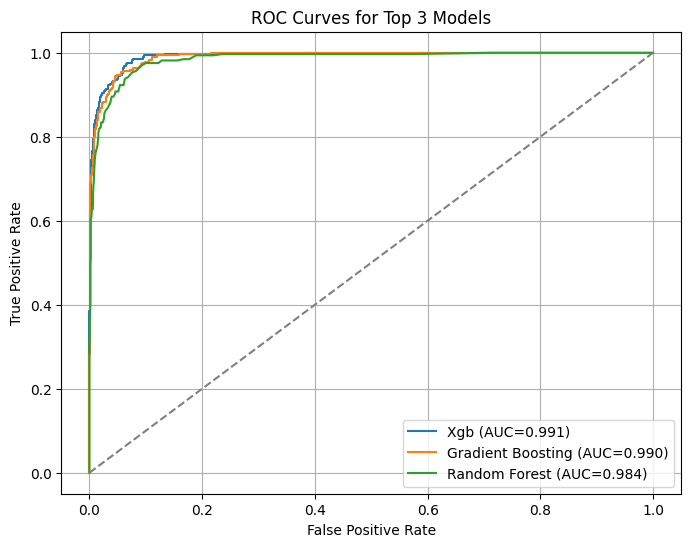

In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Top 3 models by ROC-AUC
top3 = metrics_df.head(3)["Model"].tolist()

plt.figure(figsize=(8,6))

for name in top3:
    model = best_models[name]
    if hasattr(model, "predict_proba"):  # Only models with probas
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

# Random guess line
plt.plot([0,1], [0,1], color="gray", linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Top 3 Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


***The ROC curve plot compares the performance of the top three classification models: XGBoost, Gradient Boosting, and Random Forest. Both XGBoost and Gradient Boosting achieved an impressive AUC of 0.990, while Random Forest closely followed with an AUC of 0.984. All three models demonstrate excellent discrimination between the positive and negative classes, as indicated by their ROC curves staying close to the top-left corner of the plot***



#### Confusion Matrices for Top Models

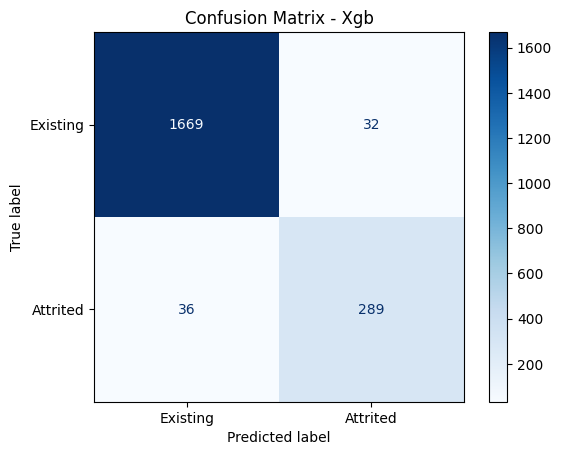

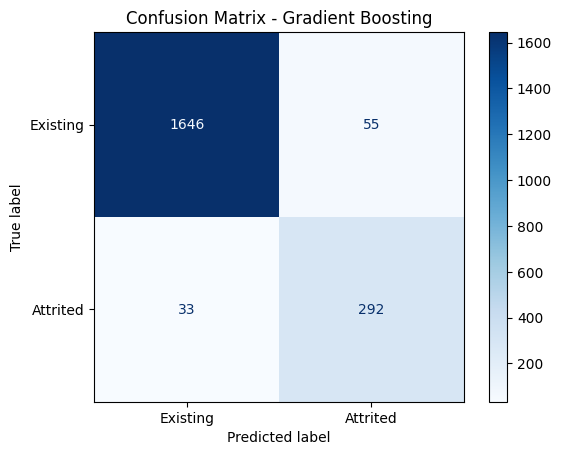

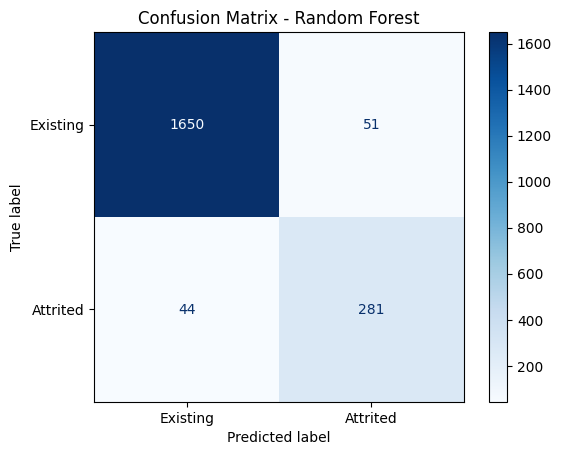

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrices for top 3 models
for name in top3:
    model = best_models[name]
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Existing","Attrited"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


#### Model Ranking (Based on Confusion Matrices)

**XGBoost – Best overall balance between precision and recall.**

**Gradient Boosting – Best recall, good if missing churners is very costly.**

**Random Forest – Reliable but lags slightly on FP and FN metrics**

------------------------------------------------------------------------------------------------------------------------
**_Primary Choice: Use XGBoost for deployment._**

**_Alternate Strategy: Use Gradient Boosting if the business goal prioritizes catching every possible churner even at the cost of a few more false positives._**

In [27]:
from sklearn.metrics import classification_report

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}:\n")
    print(classification_report(y_test, y_pred, target_names=['Existing','Attrited']))



Logistic Regression:

              precision    recall  f1-score   support

    Existing       0.95      0.86      0.91      1701
    Attrited       0.52      0.78      0.62       325

    accuracy                           0.85      2026
   macro avg       0.74      0.82      0.76      2026
weighted avg       0.88      0.85      0.86      2026


Decision Tree:

              precision    recall  f1-score   support

    Existing       0.97      0.94      0.95      1701
    Attrited       0.73      0.82      0.77       325

    accuracy                           0.92      2026
   macro avg       0.85      0.88      0.86      2026
weighted avg       0.93      0.92      0.92      2026


Random Forest:

              precision    recall  f1-score   support

    Existing       0.97      0.97      0.97      1701
    Attrited       0.85      0.86      0.86       325

    accuracy                           0.95      2026
   macro avg       0.91      0.92      0.91      2026
weighted avg     

#### Feature Importance / Explainability

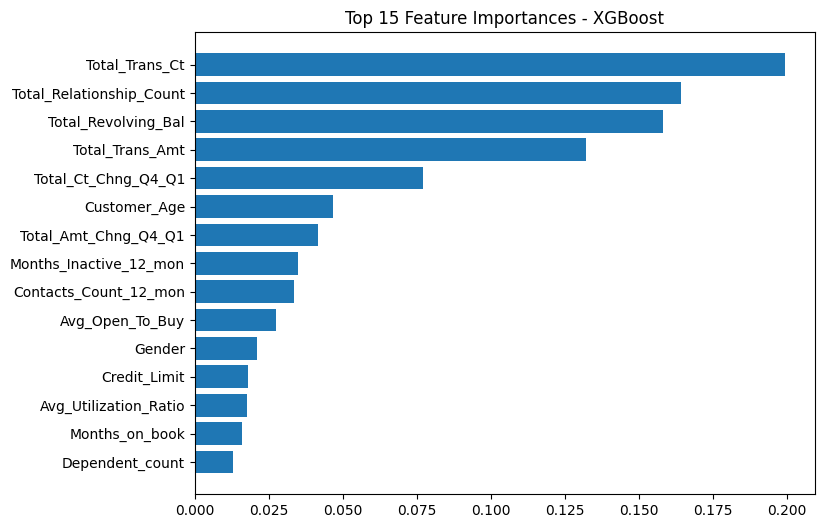

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

xgb_model = best_models['Xgb'].named_steps['model']
importances = xgb_model.feature_importances_
features = X.columns
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feat_df.Feature[:15], feat_df.Importance[:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - XGBoost")
plt.show()


In [56]:
X_train.columns

Index(['Customer_Age', 'Gender', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct'],
      dtype='object')

In [58]:
X_train.head()

,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct
2856,36,1,0,24,4,3,2,2570.0,2230,340.0,0.686,1755,42
6515,44,0,3,36,5,2,3,25276.0,0,25276.0,0.849,2282,38
7141,46,0,2,30,6,3,1,11670.0,915,10755.0,0.892,4277,89
632,36,1,2,24,3,1,3,3124.0,1593,1531.0,0.869,1652,41
3496,50,0,1,40,4,2,3,34516.0,1185,33331.0,0.725,3874,72


In [59]:
hasattr(model, "predict")

True

### Cost Evaluation 


In [34]:
from sklearn.metrics import confusion_matrix

eval_df = X_test.copy()
eval_df['y_true'] = y_test.values
eval_df['y_pred'] = y_pred  # predictions from your chosen model
eval_df['Total_Trans_Amt'] = eval_df['Total_Trans_Amt'].replace(0, 1)  # avoid div by zero

# Monthly spend proxy
eval_df['monthly_spend'] = eval_df['Total_Trans_Amt'] / eval_df['Months_on_book'].clip(lower=1)

# Estimate remaining lifetime (assume max tenure = 60 months)
eval_df['remaining_months'] = (60 - eval_df['Months_on_book']).clip(lower=1)

# Lifetime value proxy
eval_df['LTV'] = eval_df['monthly_spend'] * eval_df['remaining_months']


BASE_FN = 5000     # base cost of losing any customer
INCENTIVE_COST = 500  # cost of an unnecessary retention offer

# FN cost scales with customer LTV, FP is fixed
eval_df['FN_cost'] = BASE_FN + 0.5 * eval_df['LTV']
eval_df['FP_cost'] = INCENTIVE_COST

# Identify FP and FN cases 
FN_cases = eval_df[(eval_df['y_true'] == 1) & (eval_df['y_pred'] == 0)]
FP_cases = eval_df[(eval_df['y_true'] == 0) & (eval_df['y_pred'] == 1)]

# Compute total costs 
FN_total = FN_cases['FN_cost'].sum()
FP_total = FP_cases['FP_cost'].sum()
total_cost = FN_total + FP_total

#  STEP 5: Print detailed report
print(f"Missed churners (FN): {len(FN_cases)} → Cost: ₹{FN_total:,.0f}")
print(f"Unnecessary retention offers (FP): {len(FP_cases)} → Cost: ₹{FP_total:,.0f}")
print(f"Total Estimated Business Cost: ₹{total_cost:,.0f}")

# show top 5 most expensive missed churners
top_FN = FN_cases.sort_values(by='FN_cost', ascending=False).head(5)
print("\nTop 5 most costly missed churners:")
print(top_FN[['Total_Trans_Amt', 'Months_on_book', 'LTV', 'FN_cost']])


Missed churners (FN): 36 → Cost: ₹228,536
Unnecessary retention offers (FP): 32 → Cost: ₹16,000
Total Estimated Business Cost: ₹244,536

Top 5 most costly missed churners:
       Total_Trans_Amt  Months_on_book           LTV       FN_cost
9356              7292              18  17014.666667  13507.333333
10113            10219              36   6812.666667   8406.333333
9996              8935              35   6382.142857   8191.071429
7943              2641              18   6162.333333   8081.166667
9473              8472              37   5266.378378   7633.189189


In [37]:
import joblib

# Get the best model name by ROC-AUC
best_model_name = metrics_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

# Store model and feature order
model_data = {
    "model": best_model,
    "features": X_train_res.columns.tolist()
}

# Save to a file
joblib.dump(model_data, "xgb_model_v2.pkl")
print(f"✅ Exported {best_model_name} as xgbModel.pkl")


✅ Exported Xgb as xgbModel.pkl


📊 **Numeric Feature Summary**


,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000,2.000,3.000,5.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1162.814061,814.987335,0.0,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.0,7469.139637,9090.685324,3.0,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.0,0.759941,0.219207,0.0,0.631,0.736,0.859,3.397


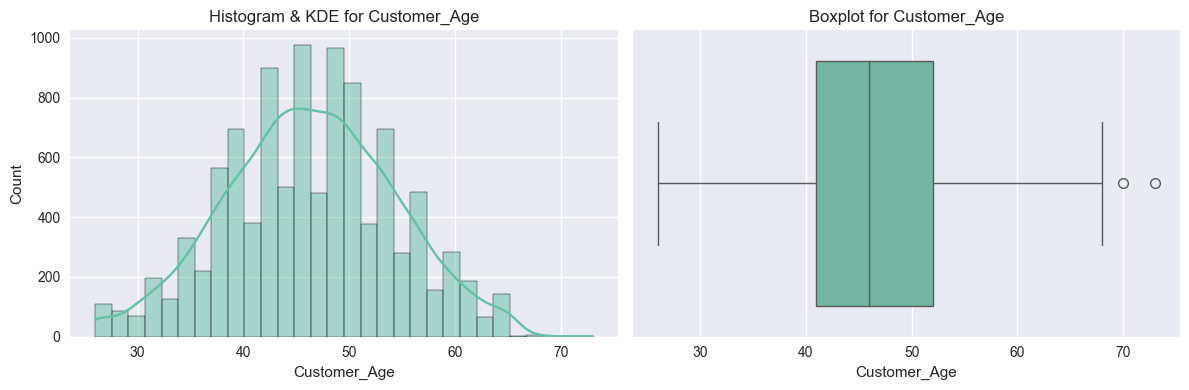

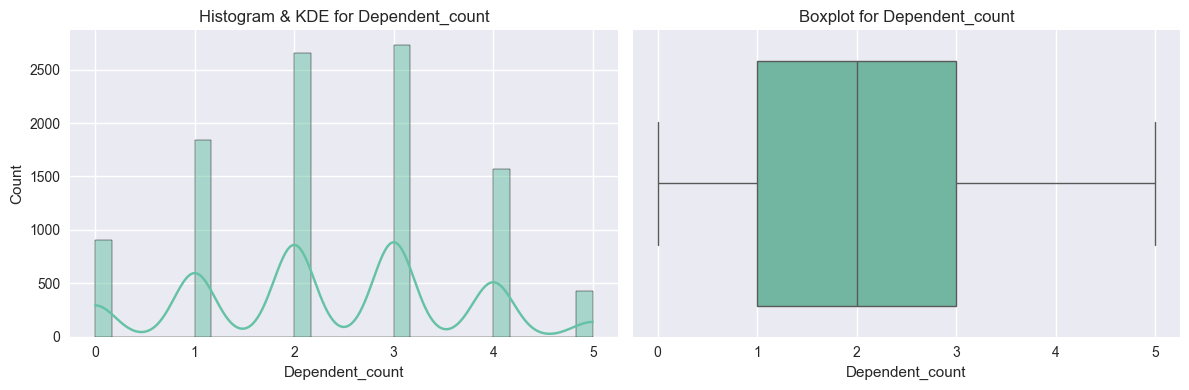

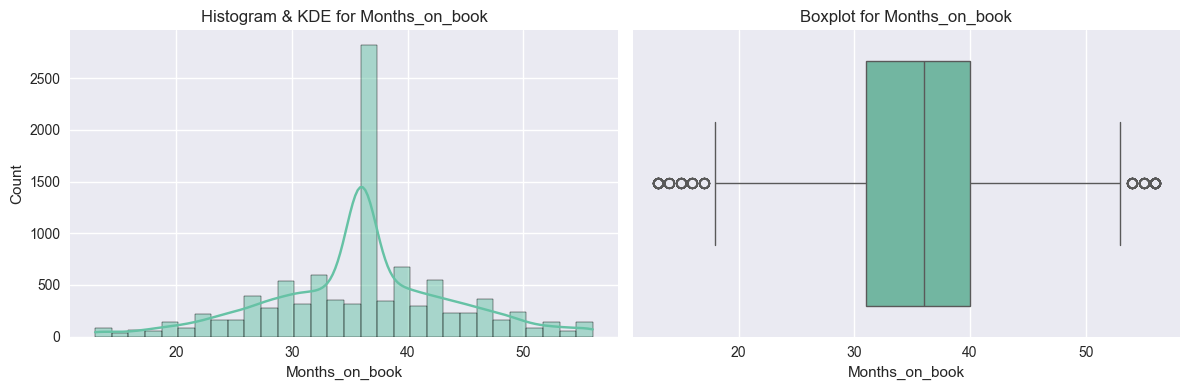

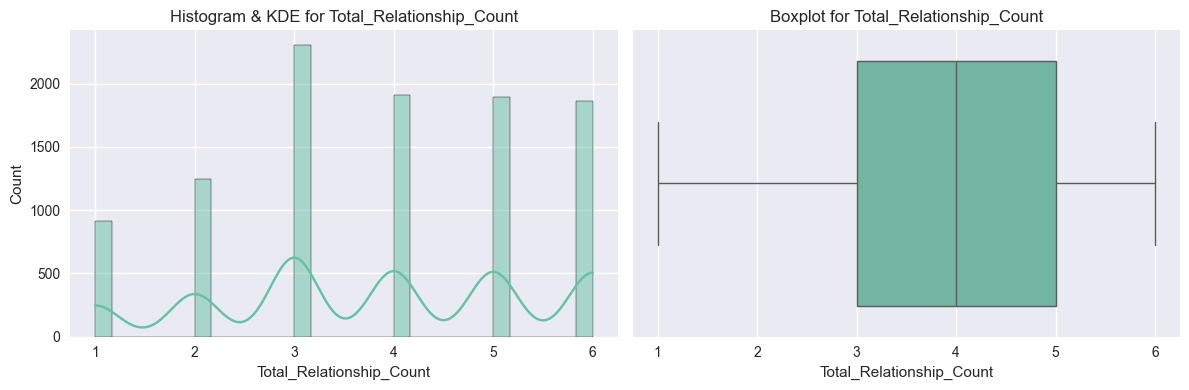

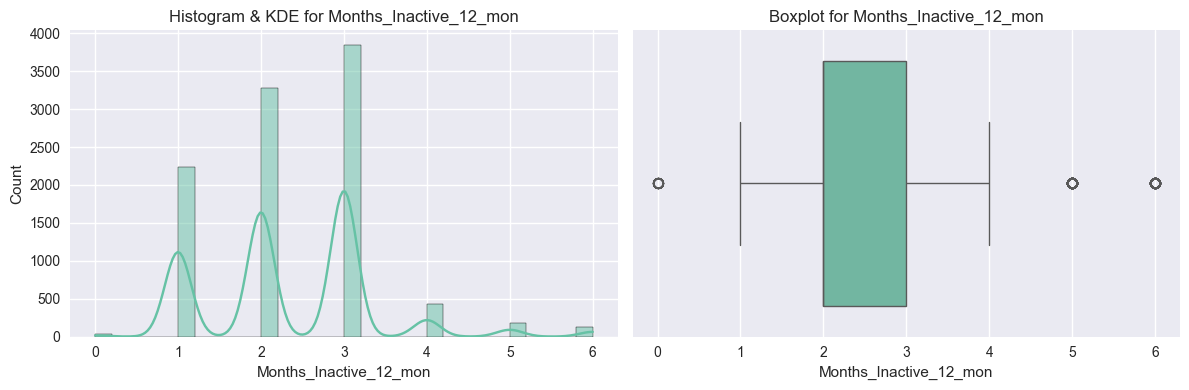

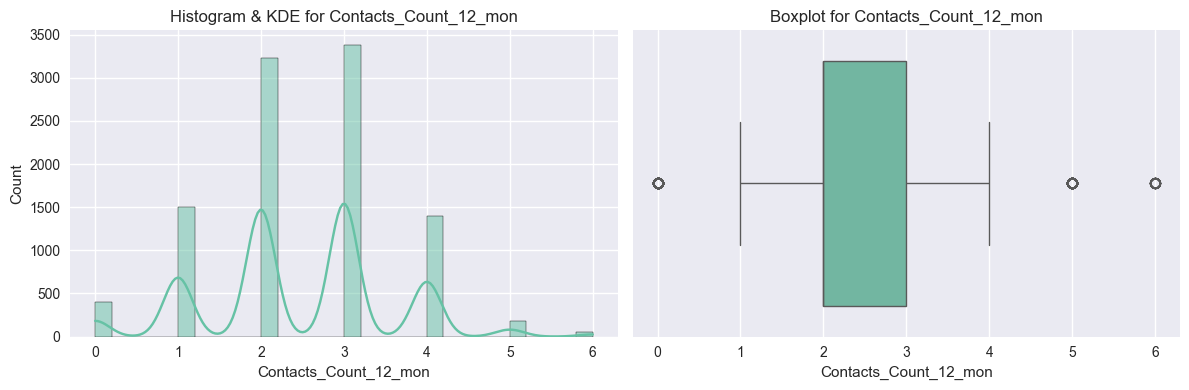

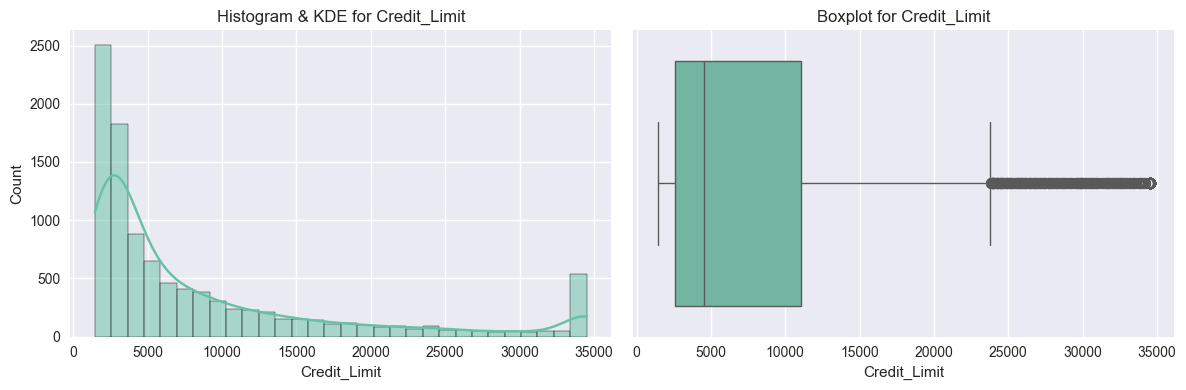

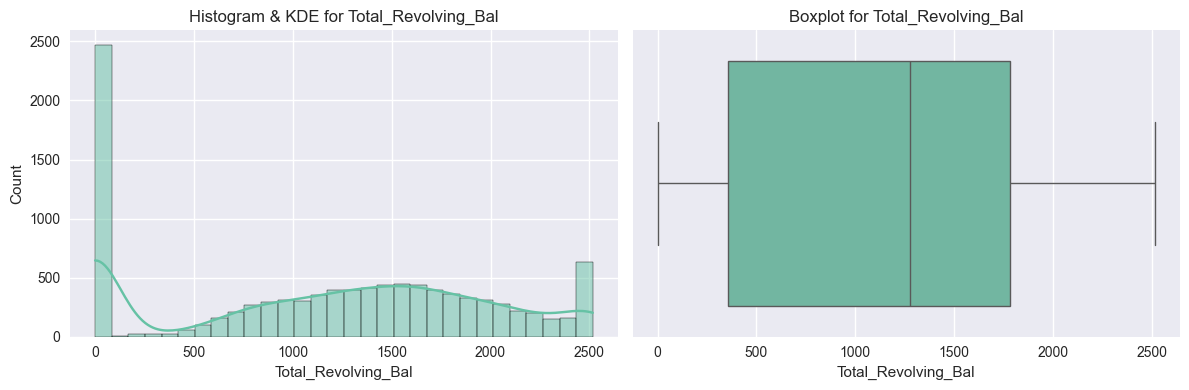

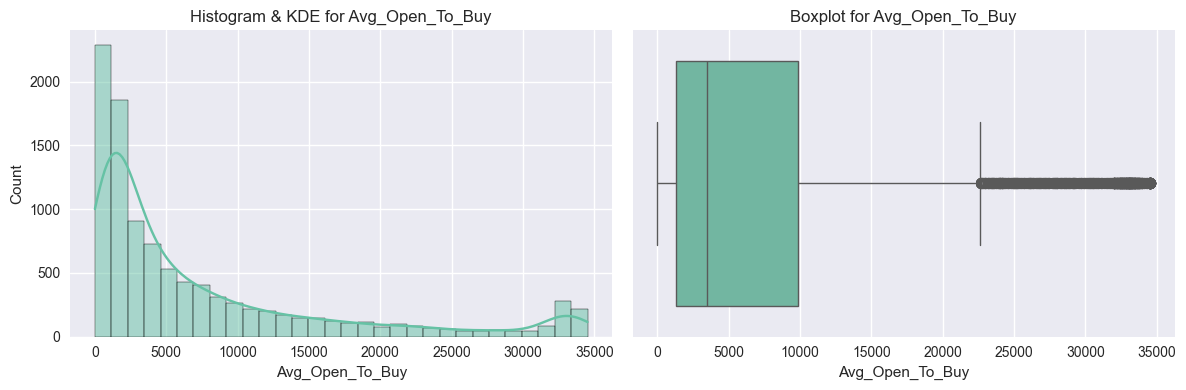

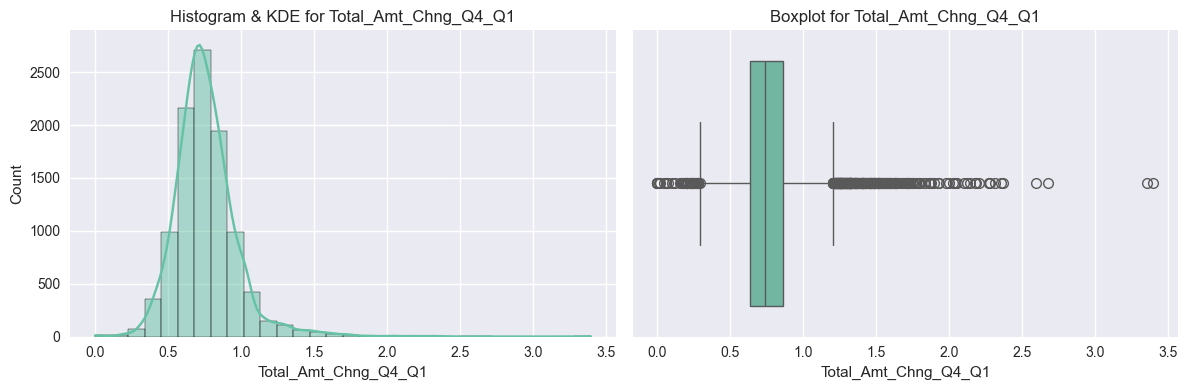

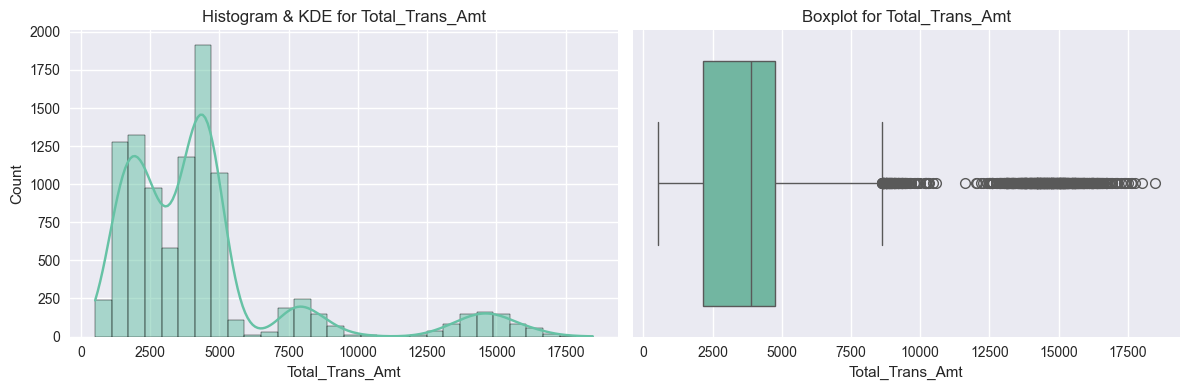

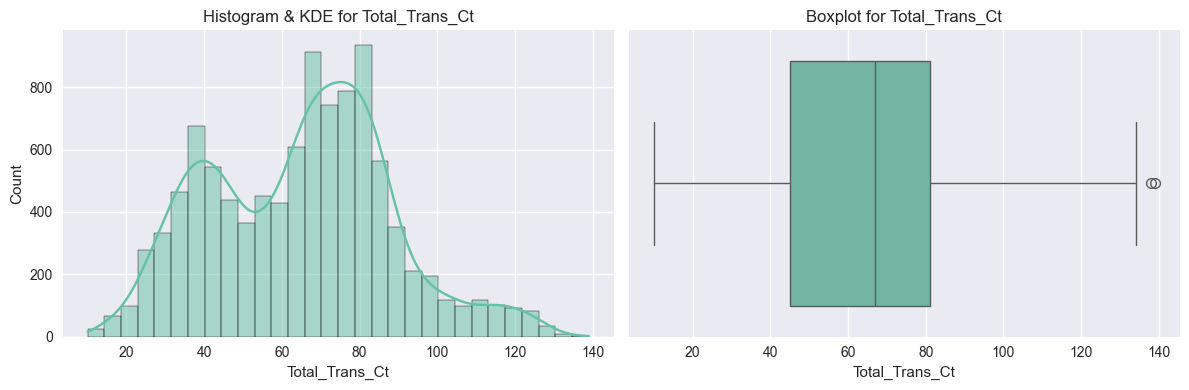

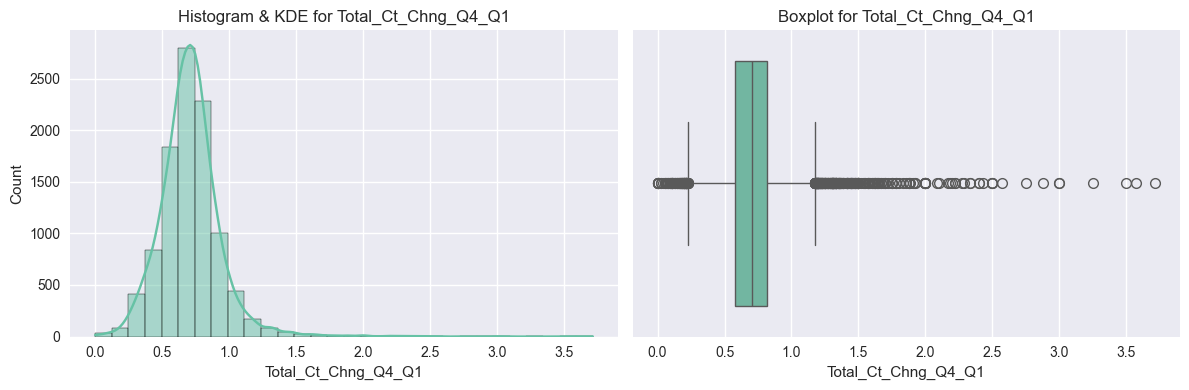

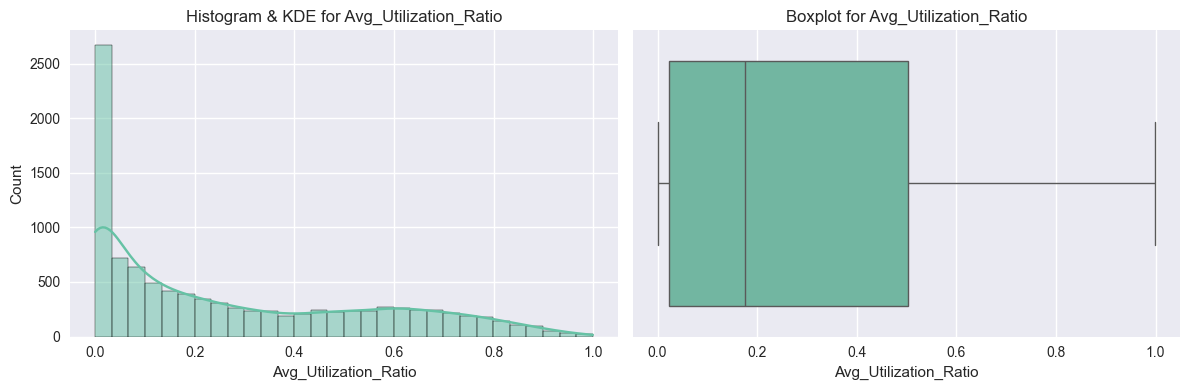

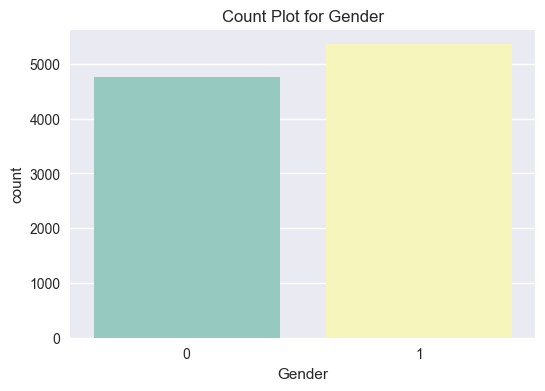

📌 **Gender Value Counts (%)**
Gender
1    52.908068
0    47.091932
Name: proportion, dtype: float64
----------------------------------------


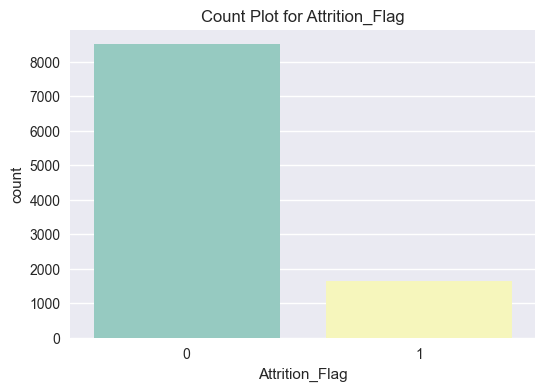

📌 **Attrition_Flag Value Counts (%)**
Attrition_Flag
0    83.934038
1    16.065962
Name: proportion, dtype: float64
----------------------------------------

🔎 Missing Values:
Attrition_Flag                    0
Customer_Age                      0
Gender                            0
Dependent_count                   0
Months_on_book                    0
Total_Relationship_Count          0
Months_Inactive_12_mon            0
Contacts_Count_12_mon             0
Credit_Limit                      0
Total_Revolving_Bal               0
Avg_Open_To_Buy                   0
Total_Amt_Chng_Q4_Q1              0
Total_Trans_Amt                   0
Total_Trans_Ct                    0
Total_Ct_Chng_Q4_Q1               0
Avg_Utilization_Ratio             0
Education_Level_Doctorate         0
Education_Level_Graduate          0
Education_Level_High School       0
Education_Level_Post-Graduate     0
Education_Level_Uneducated        0
Education_Level_Unknown           0
Income_Category_$40K - $60K     

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

# --- Detect column types ---
num_cols = ['Customer_Age','Dependent_count','Months_on_book',
            'Total_Relationship_Count','Months_Inactive_12_mon',
            'Contacts_Count_12_mon','Credit_Limit','Total_Revolving_Bal',
            'Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Amt',
            'Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio']

cat_cols = ['Gender','Attrition_Flag']  # Add churn flag here if present

# --- Summary statistics for numeric columns ---
print("📊 **Numeric Feature Summary**")
display(df[num_cols].describe().T)

# --- Plot numeric columns ---
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    sns.histplot(df[col], kde=True, ax=axes[0], bins=30)
    axes[0].set_title(f"Histogram & KDE for {col}")
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot for {col}")
    plt.tight_layout()
    plt.show()

# --- Plot categorical columns ---
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], palette='Set3')
    plt.title(f"Count Plot for {col}")
    plt.show()

    print(f"📌 **{col} Value Counts (%)**")
    print(df[col].value_counts(normalize=True)*100)
    print("-"*40)

# --- Check missing values ---
print("\n🔎 Missing Values:")
print(df.isnull().sum())
